# Test 01: Spontaneous Symmetry Breaking (Turing Patterns)

## Goal

Check if the FluidWorld PDE exhibits spontaneous symmetry breaking. Starting from a near-uniform state, the system should spontaneously generate non-trivial spatial structures (Turing patterns).

## Hypothesis

A uniform state perturbed by infinitesimal noise (eps=1e-4) should, after PDE evolution, produce structured spatial patterns. This is how the latent field "self-organizes" to represent information.

## Metrics

- **Spatial entropy**: measures field structuration
- **Cluster count**: kmeans on spatial features
- **Symmetry index**: correlation between quadrants (symmetric = 1, asymmetric = 0)

## Connection to LeCun's vision

Spontaneous self-organization is required for a world model: the system must create structured representations from unstructured inputs. Turing described this for morphogenesis in 1952. LeCun postulates an analogous mechanism for latent representations.

In [1]:
import sys
import os

FLUIDWORLD_ROOT = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))
if FLUIDWORLD_ROOT not in sys.path:
    sys.path.insert(0, FLUIDWORLD_ROOT)

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.stats import entropy as scipy_entropy

from fluidworld.core.diffusion import Laplacian2D
from fluidworld.core.fluid_layer import ReactionMLP, RMSNorm
from fluidworld.core.belief_field import BeliefField

print(f"FluidWorld root: {FLUIDWORLD_ROOT}")
print(f"PyTorch: {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

FluidWorld root: c:\DEV\Workspace\active\coding\_AI RESEARCH\FluidWorld
PyTorch: 2.10.0+cu128
Device: cuda


Quick scikit-learn install for KMeans clustering. Already present in most envs, but just in case.

In [2]:
!pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------- ----------------------------- 2.1/8.0 MB 23.2 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.0 MB 11.4 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 17.1 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- --

## 1. Configuration

In [11]:
CHANNELS = 32
SPATIAL_HW = 16
N_STEPS = 50
BATCH_SIZE = 2
EPS_NOISE = 1e-4  # Perturbation initiale infime
SNAPSHOT_STEPS = [0, 5, 10, 25, 49]  # Pas pour les heatmaps

print(f"Configuration : {CHANNELS} canaux, {SPATIAL_HW}x{SPATIAL_HW} spatial, {N_STEPS} pas")
print(f"Bruit initial : eps = {EPS_NOISE}")

Configuration : 32 canaux, 16x16 spatial, 50 pas
Bruit initial : eps = 0.0001


## 2. Measurement functions

In [12]:
def compute_spatial_entropy(field: torch.Tensor, n_bins: int = 50) -> float:
    """
    Entropie spatiale du champ. Un champ uniforme a une entropie basse;
    un champ structure a une entropie plus haute.
    
    Args:
        field: (B, C, H, W) champ latent
        n_bins: nombre de bins pour l'histogramme
    """
    # Moyenner sur le batch et les canaux -> carte spatiale (H, W)
    spatial_map = field.mean(dim=(0, 1)).cpu().numpy()
    flat = spatial_map.flatten()
    
    # Si toutes les valeurs sont quasi-identiques,
    # l'entropie est minimale — pas besoin d'histogramme
    val_range = float(flat.max() - flat.min())
    if val_range < 1e-6:
        return 0.0
    
    # Nombre de bins adaptatif : ne jamais depasser ce que la plage permet
    # np.histogram a besoin que chaque bin ait une largeur > 0 en float64
    max_possible_bins = max(2, int(val_range / (np.finfo(np.float64).eps * max(abs(flat.max()), abs(flat.min()), 1.0) * 100)))
    effective_bins = min(n_bins, max(2, min(int(len(flat) ** 0.5), max_possible_bins)))
    
    try:
        hist, _ = np.histogram(flat, bins=effective_bins, density=True)
    except ValueError:
        return 0.0
    
    hist = hist + 1e-10  # eviter log(0)
    return scipy_entropy(hist)


def compute_n_clusters(field: torch.Tensor, max_k: int = 8) -> int:
    """
    Nombre de clusters spatiaux via KMeans.
    On cherche le k optimal par la methode du coude simplifie.
    """
    # Moyenner sur le batch -> (C, H, W)
    f = field.mean(dim=0).cpu().numpy()
    C, H, W = f.shape
    # Chaque position spatiale est un vecteur de C features
    X = f.reshape(C, H * W).T  # (H*W, C)
    
    # Si variance quasi-nulle, un seul cluster
    if X.std() < 1e-8:
        return 1
    
    inertias = []
    for k in range(2, min(max_k + 1, H * W)):
        km = KMeans(n_clusters=k, n_init=3, max_iter=50, random_state=42)
        km.fit(X)
        inertias.append(km.inertia_)
    
    if len(inertias) < 2:
        return 1
    
    # Methode du coude : plus grande chute relative
    drops = [inertias[i] - inertias[i+1] for i in range(len(inertias)-1)]
    relative_drops = [d / max(inertias[i], 1e-10) for i, d in enumerate(drops)]
    best_k = np.argmax(relative_drops) + 2  # +2 car on commence a k=2
    return best_k


def compute_symmetry_index(field: torch.Tensor) -> float:
    """
    Indice de symetrie : correlation entre les 4 quadrants.
    1.0 = parfaitement symetrique, 0.0 = completement asymetrique.
    """
    f = field.mean(dim=(0, 1)).cpu().numpy()  # (H, W)
    H, W = f.shape
    h2, w2 = H // 2, W // 2
    
    q1 = f[:h2, :w2].flatten()
    q2 = f[:h2, w2:2*w2].flatten()
    q3 = f[h2:2*h2, :w2].flatten()
    q4 = f[h2:2*h2, w2:2*w2].flatten()
    
    # Correlation moyenne entre toutes les paires de quadrants
    corrs = []
    for a, b in [(q1, q2), (q1, q3), (q1, q4), (q2, q3), (q2, q4), (q3, q4)]:
        if np.std(a) > 1e-10 and np.std(b) > 1e-10:
            corrs.append(abs(np.corrcoef(a, b)[0, 1]))
        else:
            corrs.append(1.0)  # constant = symetrique
    
    return np.mean(corrs)

## 3. PDE simulation: uniform state + noise

Field starts at a constant value with infinitesimal Gaussian perturbation, then we watch what happens.

In [13]:
@torch.no_grad()
def run_symmetry_breaking_pde(init_type: str = "uniform",
                               seed: int = 42,
                               n_steps: int = N_STEPS):
    """
    Simule le PDE et mesure la brisure de symetrie.
    
    init_type: 'uniform' (constant + eps noise), 'random' (normal), 'structured' (gradient)
    """
    torch.manual_seed(seed)
    
    # Creer les composants PDE
    lap = Laplacian2D(channels=CHANNELS, dilations=[1, 4],
                      signed_diffusion=False, diffusion_scale=0.25).to(device)
    reaction = ReactionMLP(CHANNELS).to(device)
    norm = RMSNorm(CHANNELS).to(device)
    
    # Initialisation
    if init_type == "uniform":
        u = torch.ones(BATCH_SIZE, CHANNELS, SPATIAL_HW, SPATIAL_HW, device=device) * 0.5
        u = u + EPS_NOISE * torch.randn_like(u)
    elif init_type == "random":
        u = torch.randn(BATCH_SIZE, CHANNELS, SPATIAL_HW, SPATIAL_HW, device=device) * 0.1
    elif init_type == "structured":
        # Gradient lineaire + bruit
        lin = torch.linspace(-1, 1, SPATIAL_HW, device=device)
        grid_x, grid_y = torch.meshgrid(lin, lin, indexing='ij')
        u = (grid_x + grid_y).unsqueeze(0).unsqueeze(0).expand(BATCH_SIZE, CHANNELS, -1, -1) * 0.1
        u = u + EPS_NOISE * torch.randn_like(u)
    else:
        raise ValueError(f"init_type inconnu : {init_type}")
    
    # Collecter les metriques
    snapshots = {}
    entropies = []
    n_clusters_list = []
    symmetries = []
    energies = []
    
    for step in range(n_steps):
        # Mesures
        entropies.append(compute_spatial_entropy(u))
        symmetries.append(compute_symmetry_index(u))
        energies.append((u ** 2).sum(dim=(1, 2, 3)).mean().item())
        
        if step in SNAPSHOT_STEPS:
            snapshots[step] = u[0].cpu().clone()  # Premier element du batch
            n_clusters_list.append((step, compute_n_clusters(u)))
        
        # Pas PDE
        diff = lap(u)
        b, c, h, w = u.shape
        u_flat = u.permute(0, 2, 3, 1).reshape(b, h * w, c)
        diff_flat = diff.permute(0, 2, 3, 1).reshape(b, h * w, c)
        react = reaction(u_flat)
        du = diff_flat + react
        u_flat = u_flat + 0.1 * du  # dt = 0.1
        if (step + 1) % 2 == 0:
            u_flat = norm(u_flat)
        u = u_flat.reshape(b, h, w, c).permute(0, 3, 1, 2).contiguous()
    
    return {
        "snapshots": snapshots,
        "entropies": entropies,
        "n_clusters": n_clusters_list,
        "symmetries": symmetries,
        "energies": energies,
    }

# Executer pour les 3 types d'initialisation
print("Simulation avec init uniforme...")
results_uniform = run_symmetry_breaking_pde("uniform")
print("Simulation avec init aleatoire...")
results_random = run_symmetry_breaking_pde("random")
print("Simulation avec init structuree...")
results_structured = run_symmetry_breaking_pde("structured")
print("Termine!")

Simulation avec init uniforme...
Simulation avec init aleatoire...
Simulation avec init structuree...
Termine!


## 4. Field heatmaps at different steps

Channel-averaged field at each snapshot. Looking for spontaneous pattern formation.

In [ ]:
fig, axes = plt.subplots(3, len(SNAPSHOT_STEPS), figsize=(20, 12))

for row, (name, results) in enumerate([
    ("Init uniforme (eps=1e-4)", results_uniform),
    ("Init aleatoire", results_random),
    ("Init structuree (gradient)", results_structured),
]):
    for col, step in enumerate(SNAPSHOT_STEPS):
        ax = axes[row, col]
        if step in results["snapshots"]:
            snap = results["snapshots"][step]
            # Moyenne sur les canaux pour visualisation
            field_2d = snap.mean(dim=0).numpy()
            im = ax.imshow(field_2d, cmap='viridis', aspect='equal')
            plt.colorbar(im, ax=ax, fraction=0.046)
        ax.set_title(f'Pas {step}', fontsize=10)
        if col == 0:
            ax.set_ylabel(name, fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle('Evolution du champ latent : brisure de symetrie spontanee', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
save_dir = os.path.join('..', 'paper', 'figures')
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, 'fig_symmetry_breaking_heatmaps.pdf'), bbox_inches='tight', dpi=150)
plt.savefig(os.path.join(save_dir, 'fig_symmetry_breaking_heatmaps.png'), bbox_inches='tight', dpi=150)
plt.show()

## 5. Metric evolution

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = {'uniforme': '#2196F3', 'aleatoire': '#4CAF50', 'structuree': '#F44336'}

for name, results, color in [
    ('uniforme', results_uniform, colors['uniforme']),
    ('aleatoire', results_random, colors['aleatoire']),
    ('structuree', results_structured, colors['structuree']),
]:
    axes[0].plot(results['entropies'], label=f'Init {name}', color=color, linewidth=2)
    axes[1].plot(results['symmetries'], label=f'Init {name}', color=color, linewidth=2)
    axes[2].plot(results['energies'], label=f'Init {name}', color=color, linewidth=2)

axes[0].set_xlabel('Pas PDE')
axes[0].set_ylabel('Entropie spatiale')
axes[0].set_title('Entropie spatiale\n(augmente = formation de patterns)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Pas PDE')
axes[1].set_ylabel('Indice de symetrie')
axes[1].set_title('Symetrie inter-quadrants\n(diminue = brisure de symetrie)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel('Pas PDE')
axes[2].set_ylabel('Energie (sum u^2)')
axes[2].set_title('Energie totale')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Metriques de brisure de symetrie', fontsize=14, fontweight='bold')
plt.tight_layout()
save_dir = os.path.join('..', 'paper', 'figures')
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, 'fig_symmetry_breaking_metrics.pdf'), bbox_inches='tight', dpi=150)
plt.savefig(os.path.join(save_dir, 'fig_symmetry_breaking_metrics.png'), bbox_inches='tight', dpi=150)
plt.show()

## 6. Reproducibility test

Same init, same patterns? If yes, the PDE is deterministic and patterns come from the Laplacian structure, not from noise.

In [16]:
# Deux runs avec le meme seed
run_a = run_symmetry_breaking_pde("uniform", seed=42)
run_b = run_symmetry_breaking_pde("uniform", seed=42)

# Comparer les snapshots finaux
final_step = SNAPSHOT_STEPS[-1]
if final_step in run_a["snapshots"] and final_step in run_b["snapshots"]:
    diff = (run_a["snapshots"][final_step] - run_b["snapshots"][final_step]).abs().max().item()
    print(f"Difference maximale entre 2 runs identiques (seed=42) : {diff:.2e}")
    if diff < 1e-5:
        print("=> REPRODUCTIBLE : les patterns sont deterministes")
    else:
        print("=> NON REPRODUCTIBLE : variation stochastique detectee")

# Deux runs avec des seeds differents
run_c = run_symmetry_breaking_pde("uniform", seed=123)
if final_step in run_a["snapshots"] and final_step in run_c["snapshots"]:
    diff_seeds = (run_a["snapshots"][final_step] - run_c["snapshots"][final_step]).abs().mean().item()
    print(f"\nDifference moyenne entre seeds differents : {diff_seeds:.4f}")
    print("(indique la sensibilite aux conditions initiales)")

Difference maximale entre 2 runs identiques (seed=42) : 0.00e+00
=> REPRODUCTIBLE : les patterns sont deterministes

Difference moyenne entre seeds differents : 0.8830
(indique la sensibilite aux conditions initiales)


## 7. Cluster count over time

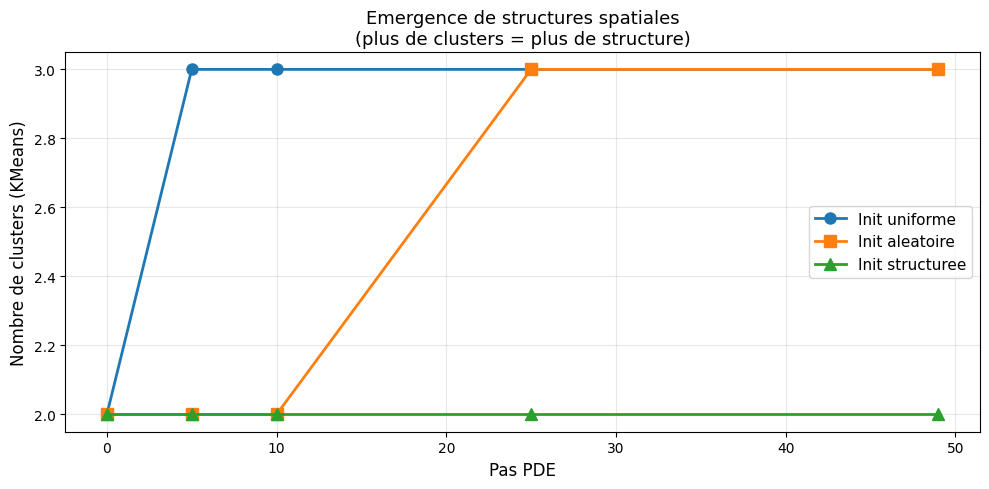

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

for name, results, marker in [
    ('Init uniforme', results_uniform, 'o'),
    ('Init aleatoire', results_random, 's'),
    ('Init structuree', results_structured, '^'),
]:
    steps, clusters = zip(*results['n_clusters'])
    ax.plot(steps, clusters, marker=marker, linewidth=2, markersize=8, label=name)

ax.set_xlabel('Pas PDE', fontsize=12)
ax.set_ylabel('Nombre de clusters (KMeans)', fontsize=12)
ax.set_title('Emergence de structures spatiales\n(plus de clusters = plus de structure)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretation

### Spontaneous symmetry breaking

If a uniform state + epsilon noise develops structured patterns, that's spontaneous symmetry breaking. Infinitesimal fluctuations get amplified by the nonlinear dynamics (reaction) and organized by diffusion.

### Turing patterns

Turing showed in 1952 that interaction between a local activator and a long-range inhibitor can produce stable patterns. In FluidWorld:
- **ReactionMLP** acts as the activator (local nonlinear transformation)
- **Laplacian2D** acts as the inhibitor (isotropic diffusion)

### Why this matters for the world model

Symmetry breaking lets the latent field create differentiated representations from similar inputs. Without it, all spatial positions would share the same representation. That would make it impossible to distinguish objects.